In [1]:
import cartopy.crs as ccrs
import intake
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import healpy as hp
import iris
import iris.plot as iplt

import easygems.healpix as egh

from utils import hp_mods, plot_all_fields

ERROR 1: PROJ: proj_create_from_database: Open of /home/users/ql935653/.conda/envs/hk26_env/share/proj failed


In [2]:
# Filter out annoying warning.
import warnings
warnings.filterwarnings("ignore", message=".*The return type of `Dataset.dims` will be changed.*", category=FutureWarning)

In [3]:
# Open catalog and print hk26 available models.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
# Use online if not on JASMIN.
# cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']
print('\n'.join([k for k in cat if k.endswith('_hk26')]))

um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_glm_n1280_CoMA9_hk26
um_glm_n1280_GAL9_v2_hk26
um_glm_n2560_CoMA9_hk26
um_glm_n2560_RAL3p3_tuned_hk26


In [4]:
# Load specific model.
sim_ral3p3 = 'um_glm_n2560_RAL3p3_tuned_hk26'
sim_cat_ral3p3 = cat[sim_ral3p3]

sim_gal9 = 'um_glm_n1280_GAL9_v2_hk26'
sim_cat_gal9 = cat[sim_gal9]

sim_CoM10 = 'um_glm_n1280_CoMA9_hk26'
sim_cat_CoM10 = cat[sim_CoM10]

sim_CoM5 = 'um_glm_n2560_CoMA9_hk26'
sim_cat_CoM5 = cat[sim_CoM5]

In [5]:
# Open a 1h (2D) and 3h (3D) dataset.
ds3h_ral3p3 = sim_cat_ral3p3(zoom=8, time='PT3H').to_dask().pipe(hp_mods)
ds3h_gal9 = sim_cat_gal9(zoom=8, time='PT3H').to_dask().pipe(hp_mods)
ds3h_CoM10 = sim_cat_CoM10(zoom=8, time='PT3H').to_dask().pipe(hp_mods)
ds3h_CoM5 = sim_cat_CoM5(zoom=8, time='PT3H').to_dask().pipe(hp_mods)

In [6]:
u850_ral3p3 = ds3h_ral3p3['ua'].sel(pressure=850)
v850_ral3p3 = ds3h_ral3p3['va'].sel(pressure=850)

u850_gal9 = ds3h_gal9['ua'].sel(pressure=850)
v850_gal9 = ds3h_gal9['va'].sel(pressure=850)

u850_CoM10 = ds3h_CoM10['ua'].sel(pressure=850)
v850_CoM10 = ds3h_CoM10['va'].sel(pressure=850)

u850_CoM5 = ds3h_CoM5['ua'].sel(pressure=850)
v850_CoM5 = ds3h_CoM5['va'].sel(pressure=850)

In [7]:
# Define function to compute number of latitude and longitude points appropriate for each Healpix zoom
# For more approximate computation, nlon ~ 4*nside; nlat ~ 3*nside
def healpix_zoom_to_grid_area_match(zoom):
    nside = 2.0**zoom

    # Healpix pixel area
    pixel_area = 4 * np.pi / (12 * nside**2)

    # Angular resolution
    theta = np.sqrt(pixel_area)

    # Compute nlon, nlat
    nlon = int(round(2 * np.pi / theta))
    nlat = int(round(np.pi / theta))

    return nlon, nlat

In [8]:
# Define function to translate from healpix to lat lon [could sit in utils.py, but showing here for transparency]
def get_nn_lon_lat_index(nside, lons, lats):
    lons2, lats2 = np.meshgrid(lons, lats)
    return xr.DataArray(
        hp.ang2pix(nside, lons2, lats2, nest=True, lonlat=True),
        coords=[("latitude", lats), ("longitude", lons)],
    )

In [9]:
# Define a function to generate iris cube from xarray Dataset
def xarray_to_iris(dataset, varname):

    # Clean up healpix attributes
    dataset["cell"].attrs.pop("standard_name", None)
    dataset["lat"].attrs.pop("standard_name", None)
    dataset["lon"].attrs.pop("standard_name", None)
    
    # Convert from xarray to iris cube
    cube = dataset[varname].to_iris()

    # Add more metadata to lat and lon coords
    for cube_coord in ["latitude", "longitude"]:
        cube.coord(cube_coord).units="degrees"
        cube.coord(cube_coord).coord_system=iris.coord_systems.GeogCS(6371229.0)
        cube.coord(cube_coord).guess_bounds()
        
    # Remove crs coord
    cube.remove_coord("crs")
    
    # Set standard_calendar for time coord
    cube.coord("time").units = cube.coord("time").units.change_calendar("standard")

    return cube

In [10]:
# OPTION B: (Recommended) Compute number of lat and lon points equivalent to Healpix zoom level
#          Note option to define lons [0,360] or [-180,180]
#          Either set bounds [lon1, lon2, lat1, lat2] based on input model domain extent, or user-specified

import ast

domain_bounds = ast.literal_eval(ds3h_ral3p3.attrs.get("regional_bounds"))
lon1 = domain_bounds["lower_left_lon"]
lon2 = domain_bounds["upper_right_lon"]
lat1 = domain_bounds["lower_left_lat"]
lat2 = domain_bounds["upper_right_lat"]

zoom_hr = 8
nlon_hr, nlat_hr = healpix_zoom_to_grid_area_match(zoom_hr)
lons_hr = np.linspace(lon1, lon2, nlon_hr)
lats_hr = np.linspace(lat1, lat2, nlat_hr)

# Get healpix_index coord corresponding to lat/lon mesh
idx_hr = get_nn_lon_lat_index(2**zoom_hr, lons_hr, lats_hr)

In [11]:
%%time

u850_ral3p3_latlon = u850_ral3p3.sel(cell=idx_hr)
v850_ral3p3_latlon = v850_ral3p3.sel(cell=idx_hr)

u850_gal9_latlon = u850_gal9.sel(cell=idx_hr)
v850_gal9_latlon = v850_gal9.sel(cell=idx_hr)

u850_CoM10_latlon = u850_CoM10.sel(cell=idx_hr)
v850_CoM10_latlon = v850_CoM10.sel(cell=idx_hr)

u850_CoM5_latlon = u850_CoM5.sel(cell=idx_hr)
v850_CoM5_latlon = v850_CoM5.sel(cell=idx_hr)

CPU times: user 5.04 s, sys: 323 ms, total: 5.36 s
Wall time: 6.76 s


In [12]:
%%time

R_e = 6371e3                   # radius of earth

def rel_vort(u, v):
    """
    vertical component of relative vorticity
    """

    lats_rad, lons_rad = u.latitude * np.pi/180, u.longitude * np.pi/180

    # 180/pi comes out when converting degrees to radians
    dv_dl = v.differentiate('longitude') * 180/np.pi

    rv = u * np.cos(lats_rad)
    rv = -rv.differentiate('latitude') * 180/np.pi
    rv += dv_dl
    rv *= 1/(R_e * np.cos(lats_rad))
    
    return rv


rv850_ral3p3_latlon = rel_vort(u850_ral3p3_latlon, v850_ral3p3_latlon)
rv850_gal9_latlon = rel_vort(u850_gal9_latlon, v850_gal9_latlon)
rv850_CoM10_latlon = rel_vort(u850_CoM10_latlon, v850_CoM10_latlon)
rv850_CoM5_latlon = rel_vort(u850_CoM5_latlon, v850_CoM5_latlon)

CPU times: user 68.3 ms, sys: 6.91 ms, total: 75.2 ms
Wall time: 74.3 ms


### that looks weird, compare to UM pp files

In [13]:
from pathlib import Path
from collections import defaultdict

# This is the main location for the simulation output.
dy3dir = Path('/gws/nopw/j04/kscale/DYAMOND3_reruns')
# We ran out of space, so some output is located under scratch.
dy3dir_scratch = Path('/work/scratch-pw5/rwjones/kscale/DYAMOND3_reruns')

In [14]:
def find_sims(dirs):
    """Returns a dict of sims, where values are another dict containing basedir, is_global and on_scratch"""
    sims = {}
    for d in dirs:
        for first_ppa in sorted(d.glob('*/*/field.pp/apvera.pp/*.apvera_20200120T0000Z.pp')):
            simkey = '.'.join(first_ppa.name.split('.')[:-2])
            basedir = first_ppa.parent.parent.parent
            is_global = 'glm' in simkey
            on_scratch = 'gws' not in str(first_ppa)
            sims[simkey] = {'basedir': basedir, 'is_global': is_global, 'on_scratch': on_scratch}
    return sims


sims = find_sims([dy3dir, dy3dir_scratch])

In [15]:
def _parse_date_from_pp_path(path):
    datestr = path.stem.split('.')[-1].split('_')[1]
    if datestr[-1] == 'Z':
        return pd.to_datetime(datestr, format="%Y%m%dT%H%MZ")
    else:
        return pd.to_datetime(datestr, format="%Y%m%dT%H")


def find_dyamond3_pp_dates_to_paths(basedir):
    """Search for pp_paths with a specific date (N.B. filename sensitive)."""
    pp_paths = sorted(basedir.glob('field.pp/apve*/**/*.pp'))
    pp_paths = [p for p in pp_paths if p.is_file()]
    dates_to_paths = defaultdict(dict)
    for path in pp_paths:
        if 'apvere' in path.stem:
            continue
        stream = path.name.split('.')[-2][5]
        dates_to_paths[_parse_date_from_pp_path(path)][stream] = path
    # Only keep completed downloads.
    dates_to_paths = {k: v for k, v in dates_to_paths.items() if len(v) == 4}
    return dates_to_paths

In [33]:
siminfo_ral3p3 = sims['glm.n2560_RAL3p3_tuned']
siminfo_gal9 = sims['glm.n1280_GAL9_v2']
siminfo_CoM10 = sims['glm.n1280_CoMA9_v2']
siminfo_CoM5 = sims['glm.n2560_CoMA9_hier_v2']

dates_to_paths_ral3p3 = find_dyamond3_pp_dates_to_paths(siminfo_ral3p3['basedir'])
dates_to_paths_gal9 = find_dyamond3_pp_dates_to_paths(siminfo_gal9['basedir'])
dates_to_paths_CoM10 = find_dyamond3_pp_dates_to_paths(siminfo_CoM10['basedir'])
dates_to_paths_CoM5 = find_dyamond3_pp_dates_to_paths(siminfo_CoM5['basedir'])

In [34]:
# We can now construct an iris cube list, loading all streams or just a single stream.
# You can apply a constraint to just load a single cube here
# Load all cubes for time:
# cubes = iris.load(dates_to_paths[pd.Timestamp('2020-01-20 00:00')].values())
# Load single stream:
cubes_ral3p3 = iris.load(dates_to_paths_ral3p3[pd.Timestamp('2020-02-01 00:00')]['c'])
cubes_gal9 = iris.load(dates_to_paths_gal9[pd.Timestamp('2020-02-01 00:00')]['c'])
cubes_CoM10 = iris.load(dates_to_paths_CoM10[pd.Timestamp('2020-02-01 00:00')]['c'])
cubes_CoM5 = iris.load(dates_to_paths_CoM5[pd.Timestamp('2020-02-01 00:00')]['c'])

/home/users/ql935653/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/fileformats/rules.py:382: IrisUserWarning: Unable to create instance of HybridHeightFactory. The source data contains no field(s) for 'orography'.
  warnings.warn(


In [37]:
%%time

u850_ral3p3_pp = cubes_ral3p3[10]
v850_ral3p3_pp = cubes_ral3p3[11]
u850_ral3p3_pp = xr.DataArray.from_iris(u850_ral3p3_pp).sel(pressure=850).sel(time='2020-02-01T03')
v850_ral3p3_pp = xr.DataArray.from_iris(v850_ral3p3_pp).sel(pressure=850).sel(time='2020-02-01T03')

u850_gal9_pp = cubes_gal9[8]
v850_gal9_pp = cubes_gal9[9]
u850_gal9_pp = xr.DataArray.from_iris(u850_gal9_pp).sel(pressure=850).sel(time='2020-02-01T03')
v850_gal9_pp = xr.DataArray.from_iris(v850_gal9_pp).sel(pressure=850).sel(time='2020-02-01T03')

u850_CoM10_pp = cubes_CoM10[9]
v850_CoM10_pp = cubes_CoM10[10]
u850_CoM10_pp = xr.DataArray.from_iris(u850_CoM10_pp).sel(pressure=850).sel(time='2020-02-01T03')
v850_CoM10_pp = xr.DataArray.from_iris(v850_CoM10_pp).sel(pressure=850).sel(time='2020-02-01T03')

u850_CoM5_pp = cubes_CoM5[9]
v850_CoM5_pp = cubes_CoM5[10]
u850_CoM5_pp = xr.DataArray.from_iris(u850_CoM5_pp).sel(pressure=850).sel(time='2020-02-01T03')
v850_CoM5_pp = xr.DataArray.from_iris(v850_CoM5_pp).sel(pressure=850).sel(time='2020-02-01T03')

CPU times: user 25.5 ms, sys: 0 ns, total: 25.5 ms
Wall time: 25.3 ms


In [38]:
%%time

rv850_ral3p3_pp = rel_vort(u850_ral3p3_pp, v850_ral3p3_pp)
rv850_ral3p3_pp = rv850_ral3p3_pp.compute()

rv850_gal9_pp = rel_vort(u850_gal9_pp, v850_gal9_pp)
rv850_gal9_pp = rv850_gal9_pp.compute()

rv850_CoM10_pp = rel_vort(u850_CoM10_pp, v850_CoM10_pp)
rv850_CoM10_pp = rv850_CoM10_pp.compute()

rv850_CoM5_pp = rel_vort(u850_CoM5_pp, v850_CoM5_pp)
rv850_CoM5_pp = rv850_CoM5_pp.compute()

CPU times: user 690 ms, sys: 377 ms, total: 1.07 s
Wall time: 979 ms


CPU times: user 1min 30s, sys: 2.61 s, total: 1min 33s
Wall time: 1min 32s


Text(0.5, 1.0, '5 km CoMA9 Healpix')

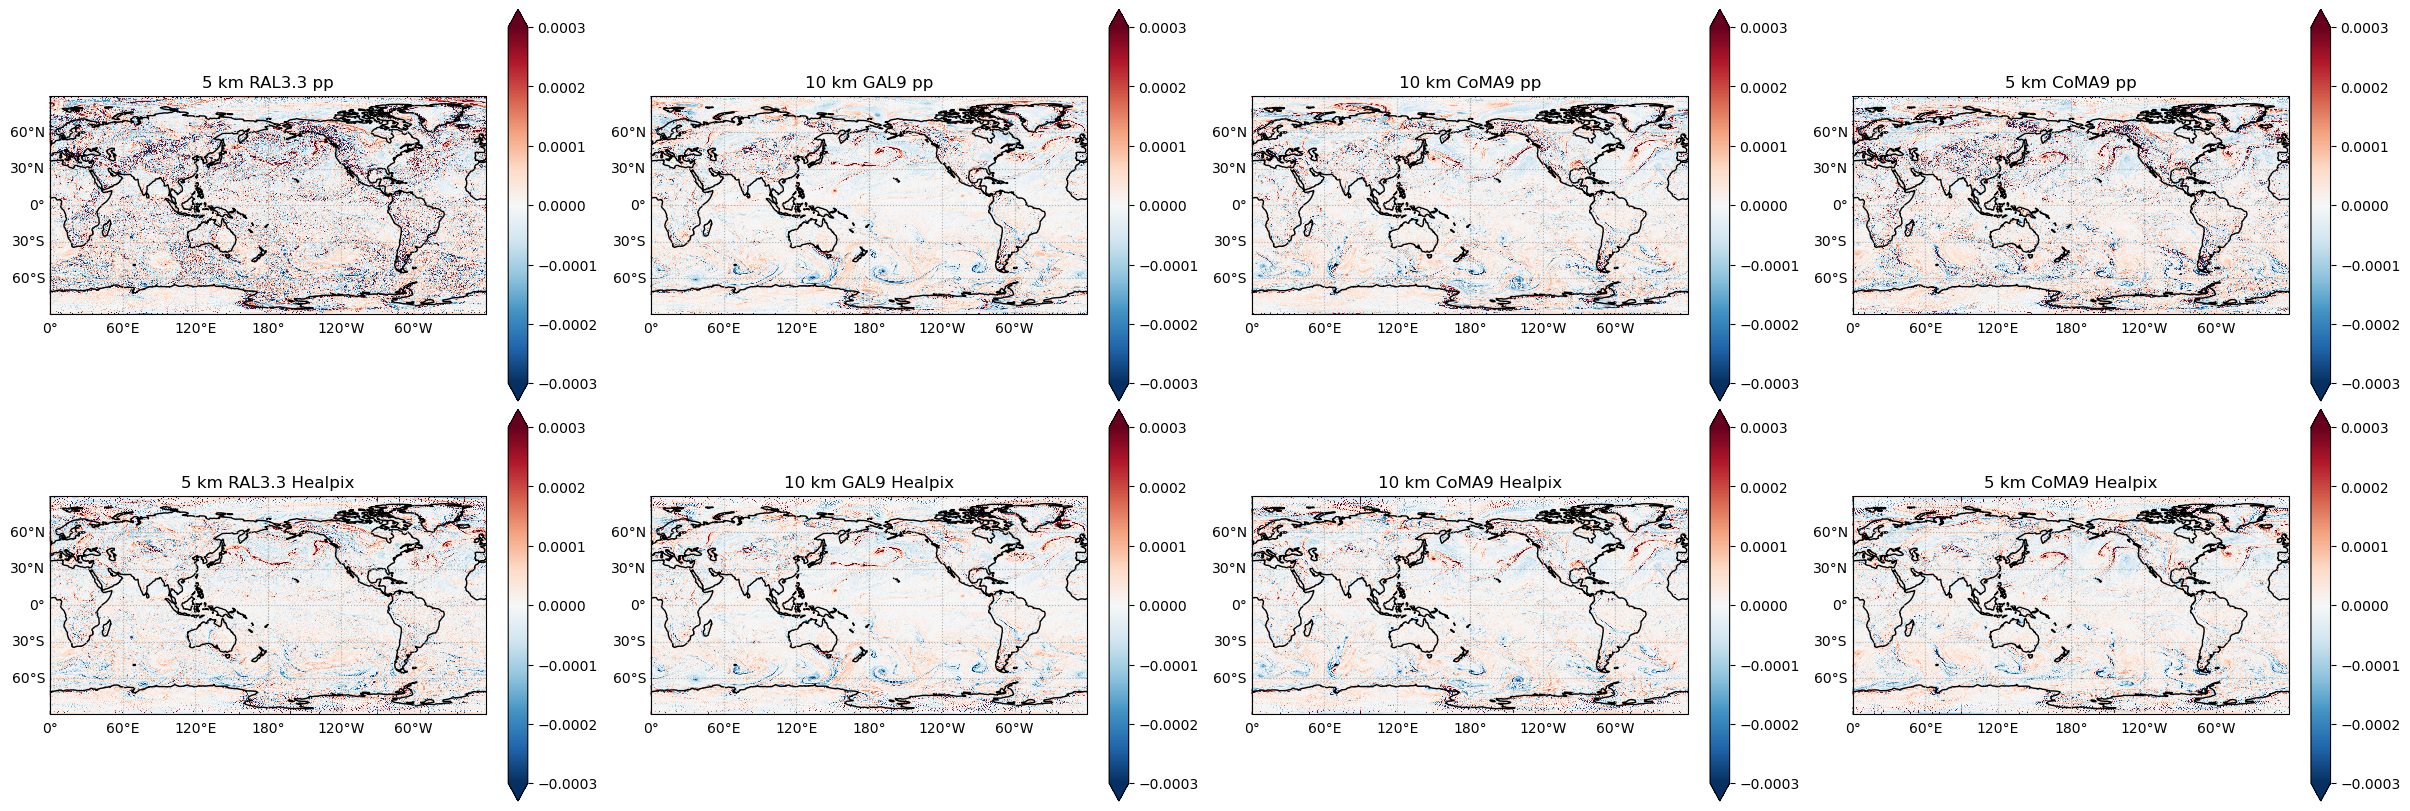

In [39]:
%%time

crs0 = projection=ccrs.PlateCarree(central_longitude=0)
crs180 = projection=ccrs.PlateCarree(central_longitude=180)

fig, axes = plt.subplots(2, 4, subplot_kw = dict(projection=crs180), figsize = (24, 8), constrained_layout=True)
# [lats_ral3p3, lons_ral3p3] = np.meshgrid(rv850_ral3p3_pp.latitude, rv850_ral3p3_pp.longitude, indexing='ij')
# [lats_gal9, lons_gal9] = np.meshgrid(rv850_gal9_pp.latitude, rv850_gal9_pp.longitude, indexing='ij')
# [lats_CoM10, lons_CoM10] = np.meshgrid(rv850_CoM10_pp.latitude, rv850_CoM10_pp.longitude, indexing='ij')
# [lats_CoM5, lons_CoM5] = np.meshgrid(rv850_CoM5_pp.latitude, rv850_CoM5_pp.longitude, indexing='ij')

for row in axes:
    for ax in row:
        ax.coastlines()
        ax.set_extent((-180, 180, -90, 90), crs=crs0)
        gl = ax.gridlines(draw_labels=True, linestyle=':')
        gl.top_labels, gl.right_labels = False, False

plt.subplot(241)
rv850_ral3p3_pp.plot(vmax=3e-4, transform=crs0)
plt.title('5 km RAL3.3 pp')

plt.subplot(242)
rv850_gal9_pp.plot(vmax=3e-4, transform=crs0)
plt.title('10 km GAL9 pp')

plt.subplot(243)
rv850_CoM10_pp.plot(vmax=3e-4, transform=crs0)
plt.title('10 km CoMA9 pp')

plt.subplot(244)
rv850_CoM5_pp.plot(vmax=3e-4, transform=crs0)
plt.title('5 km CoMA9 pp')


plt.subplot(245)
rv850_ral3p3_latlon.sel(time='2020-02-01T03').plot(vmax=3e-4, transform=crs0)
plt.title('5 km RAL3.3 Healpix')

plt.subplot(246)
rv850_gal9_latlon.sel(time='2020-02-01T03').plot(vmax=3e-4, transform=crs0)
plt.title('10 km GAL9 Healpix')

plt.subplot(247)
rv850_CoM10_latlon.sel(time='2020-02-01T03').plot(vmax=3e-4, transform=crs0)
plt.title('10 km CoMA9 Healpix')

plt.subplot(248)
rv850_CoM5_latlon.sel(time='2020-02-01T03').plot(vmax=3e-4, transform=crs0)
plt.title('5 km CoMA9 Healpix')

In [ ]:
assert False

## Calculate the circulation

In [40]:
def spherical_area_mean(data):
    """
    version without trimming (trim before entering!)
    """
    coslat = np.cos(np.deg2rad(data.latitude))
    data_mean = data * coslat
    data_mean = -data_mean.integrate(['latitude', 'longitude']) * (np.pi/180)**2 # negative sign is because lats are ordered reversely in ERA5
    box_area = get_box_area(data)
    data_mean /= box_area # normalise by box area
    
    return data_mean
    

def get_box_area(data):
    """
    get the size of the box in spherical coords
    """
    min_lon, max_lon = data['longitude'].min(), data['longitude'].max()
    min_lat, max_lat = data['latitude'].min(), data['latitude'].max()

    area = np.deg2rad(max_lon - min_lon) * (np.sin(np.deg2rad(max_lat)) - np.sin(np.deg2rad(min_lat)))
    return area

In [42]:
%%time

aus_mons_lon0, aus_mons_lon1 = 120, 150
aus_mons_lat0, aus_mons_lat1 = -20, -10

# rv850_gal9_aus_mons = rv850_gal9_latlon.sel(latitude=slice(aus_mons_lat0, aus_mons_lat1), longitude=slice(aus_mons_lon0, aus_mons_lon1))
rv850_ral3p3_aus_mons = rv850_ral3p3_latlon.sel(latitude=slice(aus_mons_lat0, aus_mons_lat1), longitude=slice(aus_mons_lon0, aus_mons_lon1))
rv850_CoM10_aus_mons = rv850_CoM10_latlon.sel(latitude=slice(aus_mons_lat0, aus_mons_lat1), longitude=slice(aus_mons_lon0, aus_mons_lon1))
rv850_CoM5_aus_mons = rv850_CoM5_latlon.sel(latitude=slice(aus_mons_lat0, aus_mons_lat1), longitude=slice(aus_mons_lon0, aus_mons_lon1))

# circ850_gal9_aus_mons = spherical_area_mean(rv850_gal9_aus_mons)
circ850_ral3p3_aus_mons = spherical_area_mean(rv850_ral3p3_aus_mons)
circ850_CoM10_aus_mons = spherical_area_mean(rv850_CoM10_aus_mons)
circ850_CoM5_aus_mons = spherical_area_mean(rv850_CoM5_aus_mons)

# circ850_gal9_aus_mons = circ850_gal9_aus_mons.compute()
circ850_ral3p3_aus_mons = circ850_ral3p3_aus_mons.compute()
circ850_CoM10_aus_mons = circ850_CoM10_aus_mons.compute()
circ850_CoM5_aus_mons = circ850_CoM5_aus_mons.compute()

CPU times: user 3min 7s, sys: 1min 23s, total: 4min 30s
Wall time: 3min 40s


In [43]:
def moving_average(data, n=24):
    data = xr.DataArray(data, dims = data.dims)#['time'])
    data = data.fillna(0)
    data = data.rolling(time=n, center=True).mean().dropna('time')
    return data

In [74]:
circ850_gal9_aus_mons_daily = moving_average(circ850_gal9_aus_mons, n=8)
circ850_ral3p3_aus_mons_daily = moving_average(circ850_ral3p3_aus_mons, n=8)
circ850_CoM10_aus_mons_daily = moving_average(circ850_CoM10_aus_mons, n=8)
circ850_CoM5_aus_mons_daily = moving_average(circ850_CoM5_aus_mons, n=8)

circ850_gal9_aus_mons_smooth = moving_average(circ850_gal9_aus_mons, n=8*45)
circ850_ral3p3_aus_mons_smooth = moving_average(circ850_ral3p3_aus_mons, n=8*45)
circ850_CoM10_aus_mons_smooth = moving_average(circ850_CoM10_aus_mons, n=8*45)
circ850_CoM5_aus_mons_smooth = moving_average(circ850_CoM5_aus_mons, n=8*45)

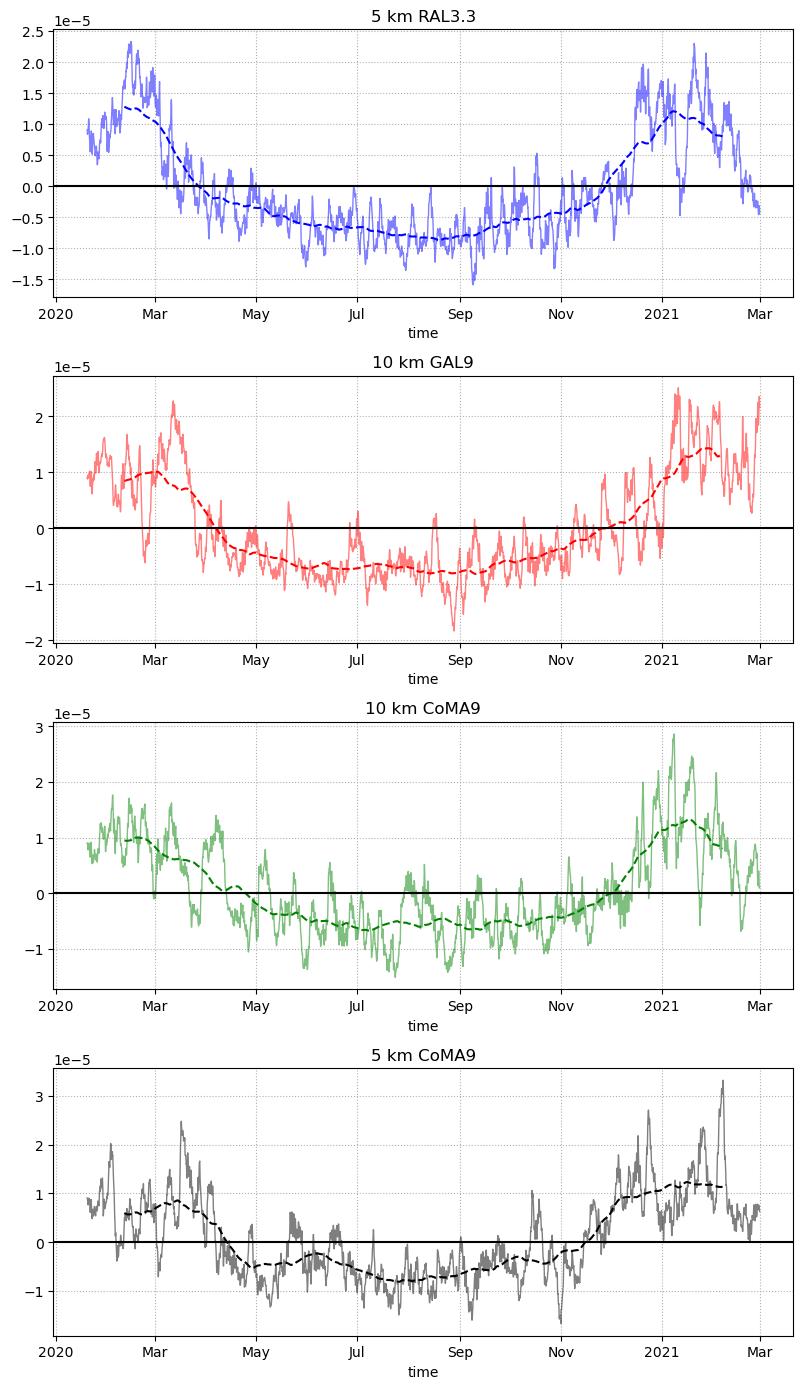

In [54]:
plt.figure(figsize=(8, 14))

plt.subplot(412)
circ850_gal9_aus_mons.plot(c='r', lw=1, alpha=0.5)
circ850_gal9_aus_mons_smooth.plot(c='r', ls='--')
plt.axhline(c='k')
plt.grid(ls=':')
plt.title('10 km GAL9')

plt.subplot(411)
circ850_ral3p3_aus_mons.plot(c='b', lw=1, alpha=0.5)
circ850_ral3p3_aus_mons_smooth.plot(c='b', ls='--')
plt.axhline(c='k')
plt.grid(ls=':')
plt.title('5 km RAL3.3')

plt.subplot(413)
circ850_CoM10_aus_mons.plot(c='g', lw=1, alpha=0.5)
circ850_CoM10_aus_mons_smooth.plot(c='g', ls='--')
plt.axhline(c='k')
plt.grid(ls=':')
plt.title('10 km CoMA9')

plt.subplot(414)
circ850_CoM5_aus_mons.plot(c='k', lw=1, alpha=0.5)
circ850_CoM5_aus_mons_smooth.plot(c='k', ls='--')
plt.axhline(c='k')
plt.grid(ls=':')
plt.title('5 km CoMA9')

plt.tight_layout()

### Plot circulation and precip against each other

In [46]:
# Open a 1h (2D) and 3h (3D) dataset.
ds1h_ral3p3 = sim_cat_ral3p3(zoom=8, time='PT1H').to_dask().pipe(hp_mods)
ds1h_gal9 = sim_cat_gal9(zoom=8, time='PT1H').to_dask().pipe(hp_mods)
ds1h_CoM10 = sim_cat_CoM10(zoom=8, time='PT1H').to_dask().pipe(hp_mods)
ds1h_CoM5 = sim_cat_CoM5(zoom=8, time='PT1H').to_dask().pipe(hp_mods)

In [47]:
precip_ral3p3 = ds1h_ral3p3['pr']
aus_mask_ral3p3 = (ds1h_ral3p3.lon > 110) & (ds1h_ral3p3.lon < 160) & (ds1h_ral3p3.lat > -45) & (ds1h_ral3p3.lat < -5)
precip_aus_ral3p3 = precip_ral3p3.where(aus_mask_ral3p3)

precip_gal9 = ds1h_gal9['pr']
aus_mask_gal9 = (ds1h_gal9.lon > 110) & (ds1h_gal9.lon < 160) & (ds1h_gal9.lat > -45) & (ds1h_gal9.lat < -5)
precip_aus_gal9 = precip_gal9.where(aus_mask_gal9)

precip_CoM10 = ds1h_CoM10['pr']
aus_mask_CoM10 = (ds1h_CoM10.lon > 110) & (ds1h_CoM10.lon < 160) & (ds1h_CoM10.lat > -45) & (ds1h_CoM10.lat < -5)
precip_aus_CoM10 = precip_CoM10.where(aus_mask_CoM10)

precip_CoM5 = ds1h_CoM5['pr']
aus_mask_CoM5 = (ds1h_CoM5.lon > 110) & (ds1h_CoM5.lon < 160) & (ds1h_CoM5.lat > -45) & (ds1h_CoM5.lat < -5)
precip_aus_CoM5 = precip_CoM5.where(aus_mask_CoM5)

In [48]:
%%time

aus_mons_mask_ral3p3 = (ds1h_ral3p3.lon > 120) & (ds1h_ral3p3.lon < 150) & (ds1h_ral3p3.lat > -20) & (ds1h_ral3p3.lat < -10)
precip_aus_mons_ral3p3 = precip_ral3p3.where(aus_mons_mask_ral3p3)
precip_aus_mons_av_ral3p3 = precip_aus_mons_ral3p3.mean('cell').compute()
precip_aus_mons_av_daily_ral3p3 = precip_aus_mons_av_ral3p3.resample(time='1D').mean()
precip_aus_mons_av_45day_ral3p3 = moving_average(precip_aus_mons_av_daily_ral3p3, n=45)

CPU times: user 42 s, sys: 8.63 s, total: 50.6 s
Wall time: 1min 16s


In [49]:
%%time

aus_mons_mask_gal9 = (ds1h_gal9.lon > 120) & (ds1h_gal9.lon < 150) & (ds1h_gal9.lat > -20) & (ds1h_gal9.lat < -10)
precip_aus_mons_gal9 = precip_gal9.where(aus_mons_mask_gal9)
precip_aus_mons_av_gal9 = precip_aus_mons_gal9.mean('cell').compute()
precip_aus_mons_av_daily_gal9 = precip_aus_mons_av_gal9.resample(time='1D').mean()
precip_aus_mons_av_45day_gal9 = moving_average(precip_aus_mons_av_daily_gal9, n=45)

CPU times: user 42.1 s, sys: 10.2 s, total: 52.3 s
Wall time: 1min 19s


In [50]:
%%time

aus_mons_mask_CoM10 = (ds1h_CoM10.lon > 120) & (ds1h_CoM10.lon < 150) & (ds1h_CoM10.lat > -20) & (ds1h_CoM10.lat < -10)
precip_aus_mons_CoM10 = precip_CoM10.where(aus_mons_mask_CoM10)
precip_aus_mons_av_CoM10 = precip_aus_mons_CoM10.mean('cell').compute()
precip_aus_mons_av_daily_CoM10 = precip_aus_mons_av_CoM10.resample(time='1D').mean()
precip_aus_mons_av_45day_CoM10 = moving_average(precip_aus_mons_av_daily_CoM10, n=45)

CPU times: user 43.1 s, sys: 9.53 s, total: 52.6 s
Wall time: 1min 17s


In [51]:
%%time

aus_mons_mask_CoM5 = (ds1h_CoM5.lon > 120) & (ds1h_CoM5.lon < 150) & (ds1h_CoM5.lat > -20) & (ds1h_CoM5.lat < -10)
precip_aus_mons_CoM5 = precip_CoM5.where(aus_mons_mask_CoM5)
precip_aus_mons_av_CoM5 = precip_aus_mons_CoM5.mean('cell').compute()
precip_aus_mons_av_daily_CoM5 = precip_aus_mons_av_CoM5.resample(time='1D').mean()
precip_aus_mons_av_45day_CoM5 = moving_average(precip_aus_mons_av_daily_CoM5, n=45)

CPU times: user 41.5 s, sys: 10.6 s, total: 52.1 s
Wall time: 1min 20s


In [56]:
import cartopy
import cartopy.mpl.geoaxes
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

/tmp/ipykernel_179/4072232710.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


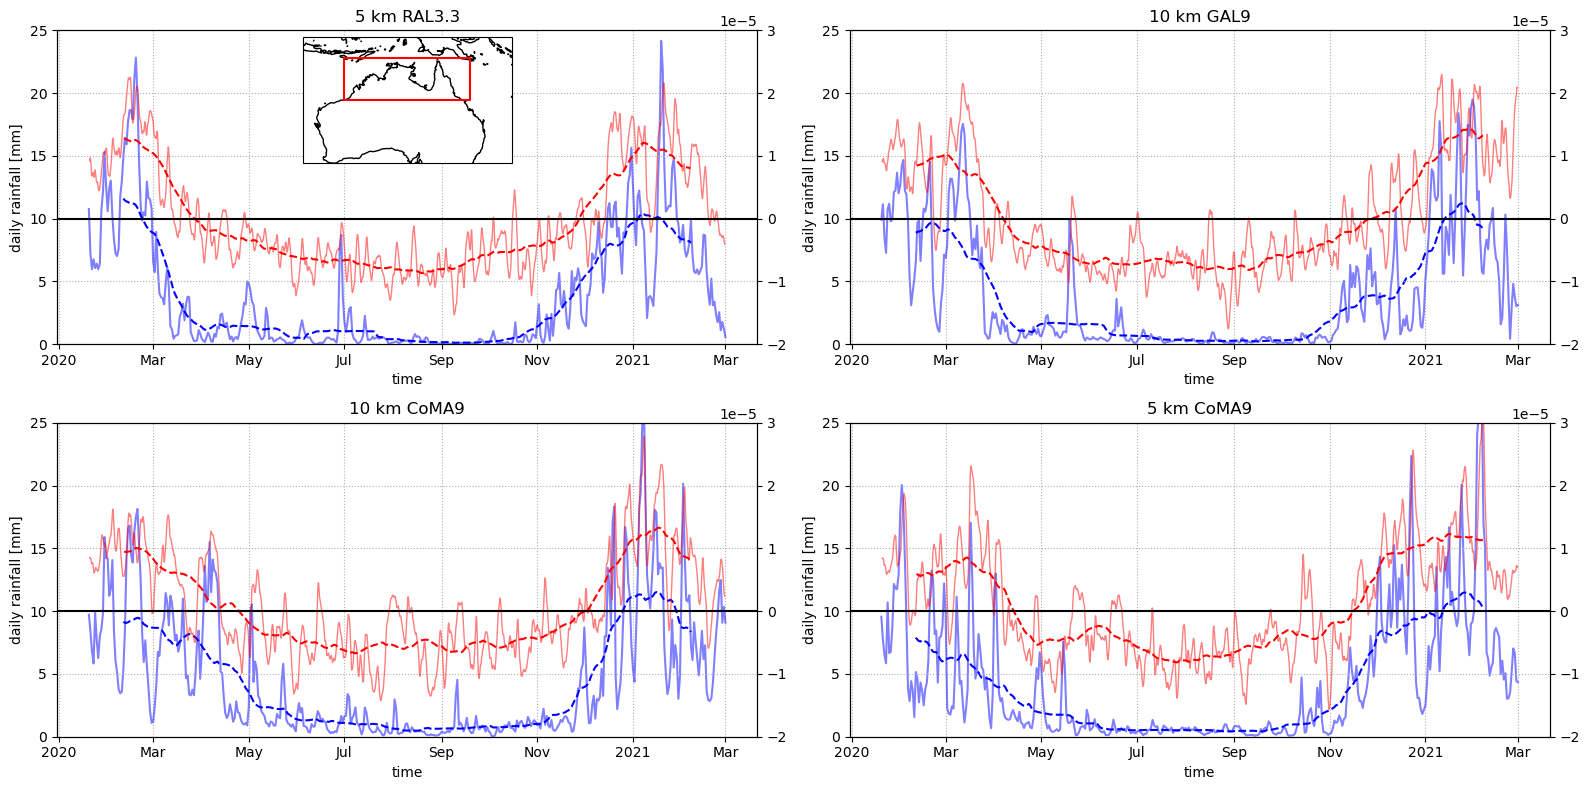

In [76]:
plt.figure(figsize=(16,8))

ax = plt.subplot(221)
(precip_aus_mons_av_daily_ral3p3*60*60*24).plot(c='b', alpha=0.5)
(precip_aus_mons_av_45day_ral3p3 *60*60*24).plot(c='b', ls='--')
plt.grid(ls=':', axis='x')
plt.ylabel('daily rainfall [mm]')
plt.ylim(0, 25)
plt.title('')
axt = ax.twinx()
circ850_ral3p3_aus_mons_daily.plot(c='r', lw=1, alpha=0.5)
circ850_ral3p3_aus_mons_smooth.plot(c='r', ls='--')
plt.grid(ls=':')
plt.axhline(c='k')
plt.ylim(-2e-5, 3e-5)
plt.title(f'5 km RAL3.3')


axins = inset_axes(ax, width="40%", height="40%", loc="upper center", 
                   axes_class=cartopy.mpl.geoaxes.GeoAxes, 
                   axes_kwargs=dict(projection=cartopy.crs.PlateCarree()))
axins.add_feature(cartopy.feature.COASTLINE)
axins.set_extent((110, 160, -35, -5), crs=crs0)
plt.plot([120, 150, 150, 120, 120], [-20, -20, -10, -10, -20], c='r')


ax = plt.subplot(222)
(precip_aus_mons_av_daily_gal9*60*60*24).plot(c='b', alpha=0.5)
(precip_aus_mons_av_45day_gal9 *60*60*24).plot(c='b', ls='--')
plt.grid(ls=':', axis='x')
plt.ylabel('daily rainfall [mm]')
plt.ylim(0, 25)
plt.title('')
axt = ax.twinx()
circ850_gal9_aus_mons_daily.plot(c='r', lw=1, alpha=0.5)
circ850_gal9_aus_mons_smooth.plot(c='r', ls='--')
plt.grid(ls=':')
plt.axhline(c='k')
plt.ylim(-2e-5, 3e-5)
plt.title(f'10 km GAL9')


ax = plt.subplot(223)
(precip_aus_mons_av_daily_CoM10*60*60*24).plot(c='b', alpha=0.5)
(precip_aus_mons_av_45day_CoM10 *60*60*24).plot(c='b', ls='--')
plt.grid(ls=':', axis='x')
plt.ylabel('daily rainfall [mm]')
plt.ylim(0, 25)
plt.title('')
axt = ax.twinx()
circ850_CoM10_aus_mons_daily.plot(c='r', lw=1, alpha=0.5)
circ850_CoM10_aus_mons_smooth.plot(c='r', ls='--')
plt.grid(ls=':')
plt.axhline(c='k')
plt.ylim(-2e-5, 3e-5)
plt.title(f'10 km CoMA9')


ax = plt.subplot(224)
(precip_aus_mons_av_daily_CoM5*60*60*24).plot(c='b', alpha=0.5)
(precip_aus_mons_av_45day_CoM5 *60*60*24).plot(c='b', ls='--')
plt.grid(ls=':', axis='x')
plt.ylabel('daily rainfall [mm]')
plt.ylim(0, 25)
plt.title('')
axt = ax.twinx()
circ850_CoM5_aus_mons_daily.plot(c='r', lw=1, alpha=0.5)
circ850_CoM5_aus_mons_smooth.plot(c='r', ls='--')
plt.grid(ls=':')
plt.axhline(c='k')
plt.ylim(-2e-5, 3e-5)
plt.title(f'5 km CoMA9')

plt.tight_layout()